In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
import numpy as np

In [32]:
file = "dvi_dim.csv"
klasteriu_sk = 3

In [33]:
df = pd.read_csv(file)
labels = df.columns.to_list()
if 'label' in labels:
    X = df.drop(columns=['label']).values
else:
    X = df

In [34]:
if file == "dvi_dim.csv":
   X_tsne = np.array(X)



In [35]:

kmeans = KMeans(n_clusters=klasteriu_sk, random_state=67)
kmeans.fit(X)
y_kmeans = kmeans.labels_

df['cluster'] = y_kmeans


In [12]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,         # sumažiname duomenų dimensijų skaičių iki 2
    perplexity=30,          # kiek artimiausių kaimynų laikoma reikšmingais
    learning_rate=200,      # nustato, kokio dydžio korekcijos taikomos kiekviename iteracijos žingsnyje
    max_iter=1000,            # iteracijų skaičius: kiek gradientinio nusileidimo žingsnių atliekama minimizuojant klaidą
    early_exaggeration=12.0,# padeda atskirti klasterius ir išvengti lokalių minimumų
    metric="euclidean",     # atstumo metrika pradinėje erdvėje
    random_state=67,        # kad rezultatai būtų atkuriami (užtikrina tą pačią pradinę taškų padėtį)
    init="pca"              # pradinė taškų pozicija nustatoma PCA pagrindu (stabiliau nei random)
)

X_tsne = tsne.fit_transform(X)


In [36]:
X_tsne

array([[  6.9497957,  27.843508 ],
       [ -4.8738   ,  14.288616 ],
       [-15.322677 ,  24.573948 ],
       ...,
       [ 35.672195 , -23.179432 ],
       [ 36.559723 , -22.971228 ],
       [ 20.105444 ,  -6.5285044]])

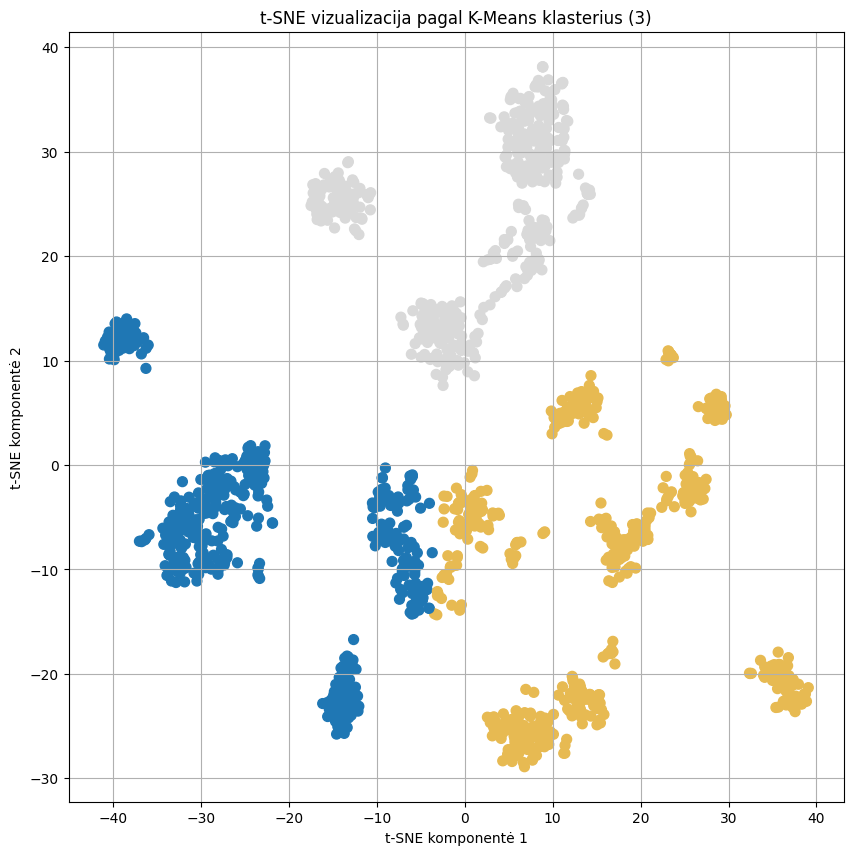

In [37]:
plt.figure(figsize=(10, 10))
colors = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
cmap = ListedColormap(colors)

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_kmeans,
    cmap=cmap,
    s=50
)
plt.title(f"t-SNE vizualizacija pagal K-Means klasterius ({klasteriu_sk})")
plt.xlabel("t-SNE komponentė 1")
plt.ylabel("t-SNE komponentė 2")
plt.grid(True)
plt.show()
